# Quantum Computing Lab - Assignment 5
## Mrudula A Mahindrakar
### EE25S011

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import HamiltonianGate
from qiskit import transpile
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator

from qiskit_ibm_runtime.fake_provider import FakeAthensV2
from qiskit_aer.noise import NoiseModel

from scipy.linalg import expm
import warnings
from numpy.linalg import solve, eig

# Problem 1: HHL Algorithm

To solve the linear system of equation: $A∣x⟩=∣b⟩$

A = $\begin{pmatrix} 1 & 0 & 0 & -1  \\\\ 0 & 1 & 0 & 0 \\\\ 0 & 0 & 1 & 0 \\\\ 1 & 0 & 0 & 1\end{pmatrix}$
b $ \in \{ \begin{pmatrix} 1 \\\\ 0 \\\\ 0 \\\\ 0 \end{pmatrix}, \begin{pmatrix} 0 \\\\ 1 \\\\ 0 \\\\ 0 \end{pmatrix}, \begin{pmatrix} 0 \\\\ 0 \\\\ 1 \\\\ 0 \end{pmatrix}, \begin{pmatrix} 0 \\\\ 0 \\\\ 0 \\\\ 1 \end{pmatrix} \}$

A is not hermitian, so we define

C = $\begin{pmatrix} 0 & A \\\\ A^+ & 0 \end{pmatrix}$

So that $\begin{pmatrix} 0 & A \\\\ A^+ & 0 \end{pmatrix}$ . $\begin{pmatrix} 0 \\\\ x \end{pmatrix}$ = $\begin{pmatrix} b \\\\ 0 \end{pmatrix}$

In [2]:
# Define Matrix and Analyze Spectrum
A = np.array([[1, 0, 0, -1],
                   [0, 1, 0, 0],
                   [0, 0, 1, 0],
                   [1, 0, 0, 1]], dtype=complex)

eigvals, eigvecs = eig(A)

print("Eigenvalues:")
print(eigvals)

basis_vectors = [
    np.array([1,0,0,0], dtype=complex),
    np.array([0,1,0,0], dtype=complex),
    np.array([0,0,1,0], dtype=complex),
    np.array([0,0,0,1], dtype=complex)
]

Eigenvalues:
[1.+1.j 1.-1.j 1.+0.j 1.+0.j]


In [3]:
def classical_solution(A, b):
    return solve(A, b)

for i, b in enumerate(basis_vectors):
    x = classical_solution(A, b)
    print(f"Solution for basis vector {i}:")
    print(x)

Solution for basis vector 0:
[ 0.5+0.j  0. +0.j  0. +0.j -0.5+0.j]
Solution for basis vector 1:
[0.+0.j 1.+0.j 0.+0.j 0.+0.j]
Solution for basis vector 2:
[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
Solution for basis vector 3:
[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]


In [4]:
A_dag = A.conj().T
zeros = np.zeros((4, 4))
C = np.block([[zeros, A],
              [A_dag, zeros]])

eigvals_C = np.linalg.eigvals(C)
print("Eigenvalues of C:", np.round(eigvals_C, 6))
lambda_max = np.max(np.abs(eigvals_C))

t = np.pi / (2 * np.sqrt(2))

print(f"\nEvolution time t = pi/(2*sqrt(2)) = {t:.6f}")
print("Matrix C is Hermitian:", np.allclose(C, C.conj().T))
print("Matrix C shape:", C.shape)


Eigenvalues of C: [ 1.414214+0.j -1.414214+0.j  1.      +0.j -1.      +0.j  1.414214+0.j
  1.      +0.j -1.414214+0.j -1.      +0.j]

Evolution time t = pi/(2*sqrt(2)) = 1.110721
Matrix C is Hermitian: True
Matrix C shape: (8, 8)


In [5]:
def controlled_U(circuit, clock, system, C, t):
    sys_qubits = list(system)
    for i in range(len(clock)):
        U = HamiltonianGate(C, t * (2**i),label ="CU")
        CU = U.control()
        circuit.append(CU, [clock[i]] + sys_qubits)

In [6]:
def conditional_rotation(circuit, clock, ancilla, t):

    n = len(clock)
    num_states = 2 ** n
    C_norm = 1.0

    for k in range(1, num_states):
        # Reconstruct signed lambda from QPE integer k
        if k > num_states // 2:
            lam_recon = (k - num_states) / num_states * (2 * np.pi / t)
        else:
            lam_recon = k / num_states * (2 * np.pi / t)

        # Inversion rotation angle
        ratio = np.clip(C_norm / lam_recon, -1.0, 1.0)
        theta = 2 * np.arcsin(ratio)

        # turn |k> into |111...>
        k_bin = format(k, f'0{n}b')
        flip_qubits = [clock[i] for i in range(n) if k_bin[i] == '0']
        if flip_qubits:
            circuit.x(flip_qubits)

        circuit.mcry(theta, list(clock), ancilla)

        if flip_qubits:
            circuit.x(flip_qubits)


In [8]:
def qpe(circuit, clock, system, C, t):

    circuit.h(clock)
    controlled_U(circuit, clock, system, C, t)
    circuit.append(QFT(len(clock)).inverse(), clock)

def inv_qpe(circuit, clock, system, C, t):

    circuit.append(QFT(len(clock)), clock)
    controlled_U(circuit, clock, system, C, -t)
    circuit.h(clock)

In [9]:
def build_hhl_circuit(C, b, num_phase_qubits, n_system, n_clock,t):

    qr_a = QuantumRegister(1, 'ancilla')
    qr_c = QuantumRegister(n_clock, 'clock')
    qr_s = QuantumRegister(n_system, 'system')
    cr   = ClassicalRegister(n_system + 1, 'meas')

    qc = QuantumCircuit(qr_a, qr_c, qr_s, cr)

    # b_padded = [b; 0]
    b_padded = np.concatenate([b, np.zeros(len(C) - len(b))])
    b_padded = b_padded / np.linalg.norm(b_padded)
    qc.initialize(b_padded, qr_s)

    qpe(qc, qr_c, qr_s, C, t)
    conditional_rotation(qc, qr_c, qr_a, t)   # <-- pass t
    inv_qpe(qc, qr_c, qr_s, C, t)

    qc.save_statevector()
    qc.measure(qr_a, cr[0])
    qc.measure(qr_s, cr[1:])

    return qc


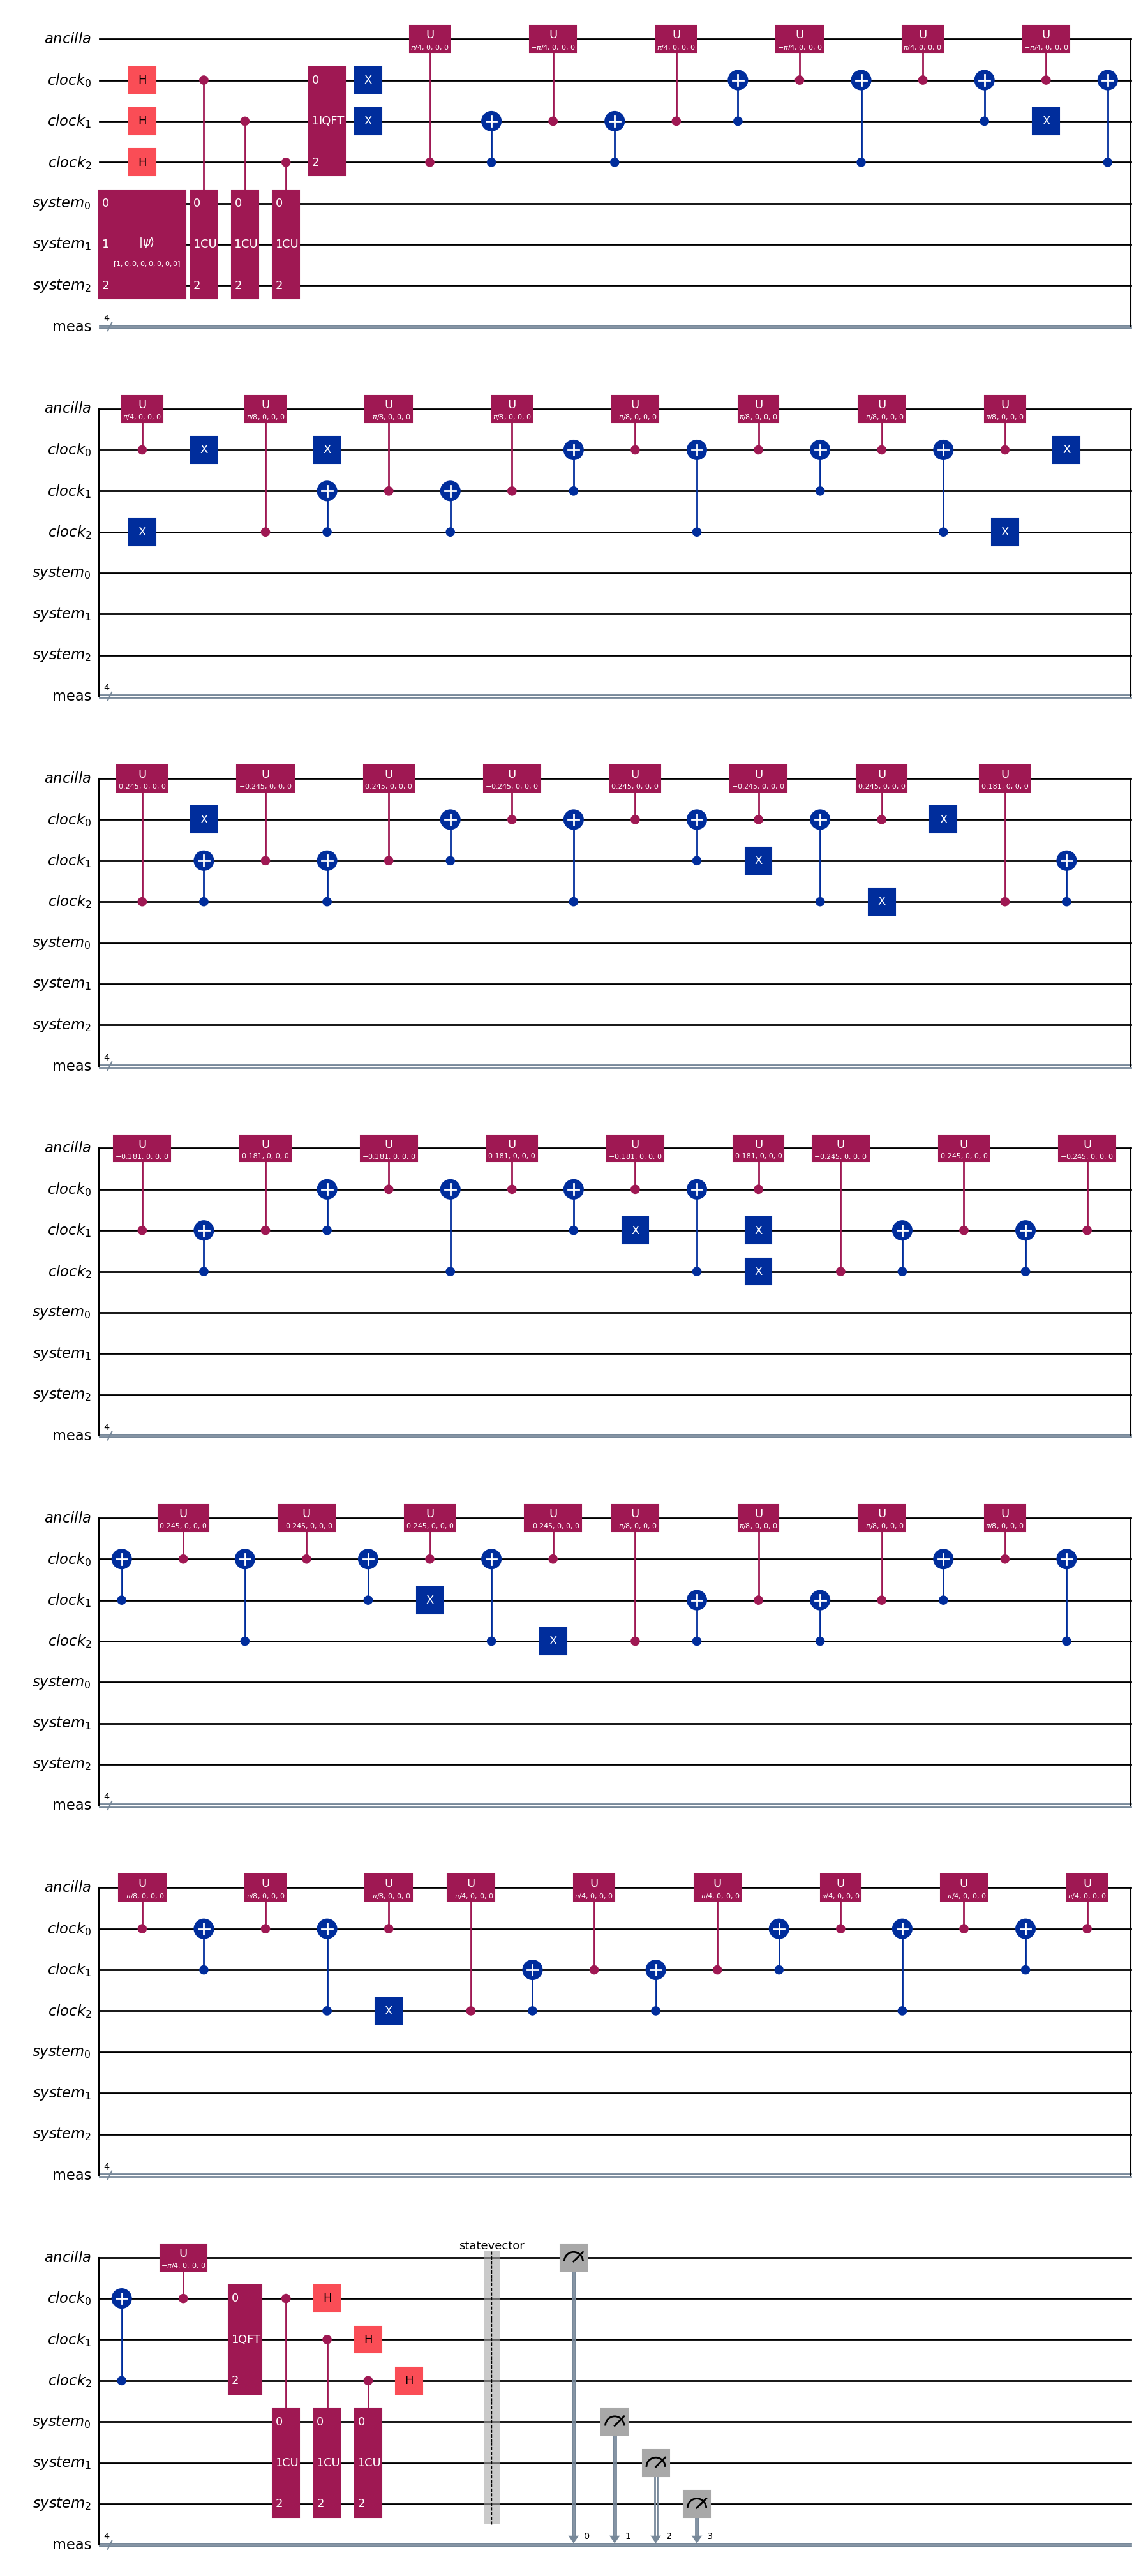

In [10]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

n_system = 3          # 8-dimensional space
n_clock = 3           # precision qubits
num_phase_qubits = 3

qc = build_hhl_circuit(C, basis_vectors[0],num_phase_qubits,n_system,n_clock,t)
qc.draw("mpl")

In [11]:
def run_experiment(sim_type, simulator):
    print(f"  Running on {sim_type} Simulator \n")

    all_results = []
    stride = 2 ** (1 + n_clock)   # = 16 with n_clock=3
    n_orig = len(basis_vectors[0]) # = 4

    for i, b in enumerate(basis_vectors):
        qc = build_hhl_circuit(C, b, num_phase_qubits, n_system, n_clock,t)
        t_qc = transpile(qc, simulator)
        result = simulator.run(t_qc, shots=8192).result()
        counts = result.get_counts()

        success = {k: v for k, v in counts.items() if k[-1] == '1'}

        print(f"\nb_{i}   |  Counts (ancilla=1): {success}")

        # After HHL the solution x lives in the LOWER half of the system register.
        sv = result.data(t_qc)['statevector'] if 'statevector' in result.data(t_qc) else None
        if sv is not None:
            n_sys_half = len(C) // 2
            sol_idx = [(n_sys_half + j) * stride + 1 for j in range(n_orig)]
            x_q = np.array([sv[idx] for idx in sol_idx])
            x_q[np.abs(x_q) < 1e-6] = 0
            norm = np.linalg.norm(x_q)
            if norm > 0:
                x_q_norm = x_q / norm
                x_cl = classical_solution(A, b)
                x_cl_norm = x_cl / np.linalg.norm(x_cl)
                match = np.allclose(np.abs(x_q_norm), np.abs(x_cl_norm), atol=0.05)
                print(f"      |  Quantum  (norm): {np.round(x_q_norm, 3)}")
                print(f"      |  Classical(norm): {np.round(x_cl_norm, 3)}")
                print(f"      |  Matching?          : {match}")

        all_results.append(result)

    return all_results


In [12]:
ideal_sim = AerSimulator()
warnings.filterwarnings("ignore", category=DeprecationWarning)

ideal_results = run_experiment("Ideal", ideal_sim)

  Running on Ideal Simulator 


b_0   |  Counts (ancilla=1): {'1001': 57, '0001': 2869, '1111': 45}
      |  Quantum  (norm): [-0.707+0.j  0.   +0.j  0.   +0.j  0.707+0.j]
      |  Classical(norm): [ 0.707+0.j  0.   +0.j  0.   +0.j -0.707+0.j]
      |  Matching?          : True

b_1   |  Counts (ancilla=1): {'1011': 3033, '0011': 856}
      |  Quantum  (norm): [ 0.+0.j -1.-0.j  0.+0.j  0.+0.j]
      |  Classical(norm): [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
      |  Matching?          : True

b_2   |  Counts (ancilla=1): {'1101': 3001, '0101': 873}
      |  Quantum  (norm): [ 0.+0.j  0.+0.j -1.-0.j  0.+0.j]
      |  Classical(norm): [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
      |  Matching?          : True

b_3   |  Counts (ancilla=1): {'1111': 62, '0111': 2904, '1001': 55}
      |  Quantum  (norm): [-0.707-0.j  0.   +0.j  0.   +0.j -0.707-0.j]
      |  Classical(norm): [0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]
      |  Matching?          : True


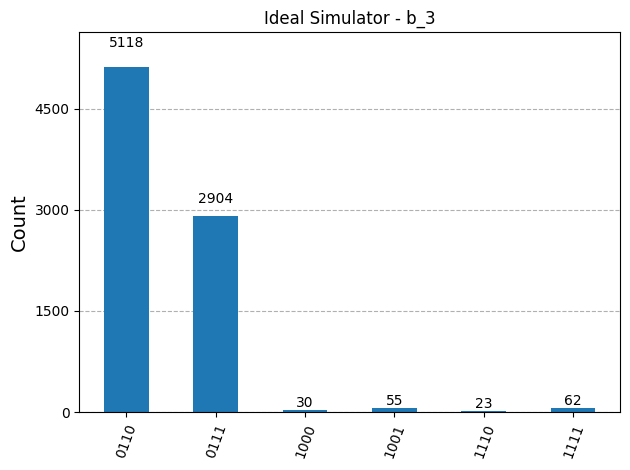

In [13]:
# Plot histogram for last b vector
last_counts = ideal_results[-1].get_counts()
display(plot_histogram(last_counts, title="Ideal Simulator - b_3"))

In [14]:
fake_backend = FakeAthensV2()
noise_model = NoiseModel.from_backend(fake_backend)
noisy_sim = AerSimulator(noise_model=noise_model)
warnings.filterwarnings("ignore", category=DeprecationWarning)

noisy_results = run_experiment("Noisy", noisy_sim)


  Running on Noisy Simulator 


b_0   |  Counts (ancilla=1): {'1111': 383, '0011': 326, '1001': 512, '0001': 1371, '1011': 293, '0111': 119, '0101': 90, '1101': 88}
      |  Quantum  (norm): [ 0.568+0.105j  0.21 -0.778j -0.053+0.12j   0.007-0.015j]
      |  Classical(norm): [ 0.707+0.j  0.   +0.j  0.   +0.j -0.707+0.j]
      |  Matching?          : False

b_1   |  Counts (ancilla=1): {'1011': 1372, '0011': 1056, '0001': 375, '1001': 329, '1111': 104, '0111': 77, '0101': 49, '1101': 58}
      |  Quantum  (norm): [ 0.001-0.001j -0.922-0.388j -0.   +0.j     0.   -0.j   ]
      |  Classical(norm): [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
      |  Matching?          : True

b_2   |  Counts (ancilla=1): {'1101': 1444, '0011': 51, '0101': 1065, '0111': 336, '1001': 92, '0001': 79, '1111': 362, '1011': 52}
      |  Quantum  (norm): [-0.   +0.j     0.   -0.j    -0.919+0.395j  0.001-0.001j]
      |  Classical(norm): [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
      |  Matching?          : True

b_3   |  Counts (ancilla=

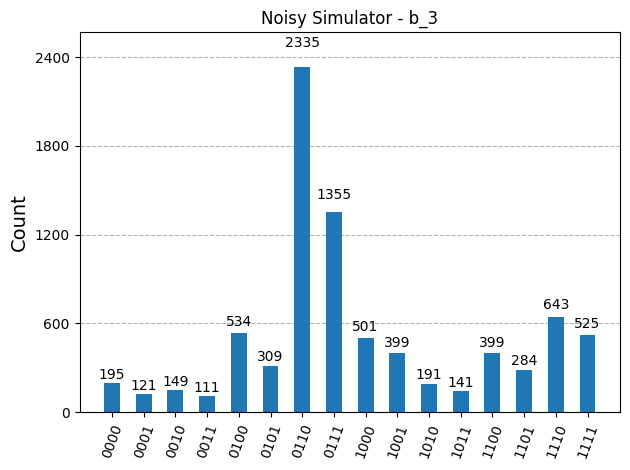

In [15]:
# Plot histogram for last b vector
last_counts_noisy = noisy_results[-1].get_counts()
display(plot_histogram(last_counts_noisy, title="Noisy Simulator - b_3"))

## Part b

In [16]:
import numpy as np
from scipy.linalg import solve

# A_9: [[1,0,-1],[0,I_7x7,0],[1,0,1]]
A_9 = np.eye(9, dtype=complex)
A_9[0, 8] = -1
A_9[8, 0] =  1

print("A_9 matrix:")
print(np.real(A_9))

b_9 = np.zeros(9)
b_9[1] = 1   # b = |1>
print("\nb vector:", b_9)

x_classical = solve(A_9, b_9)
print("\nClassical solution x:", x_classical)

# Pad A_9 to next power-of-2 size (16x16)
A_16 = np.eye(16, dtype=complex)
A_16[0:9, 0:9] = A_9

# Build Hermitian C
zeros_16 = np.zeros((16, 16), dtype=complex)
C_32 = np.block([[zeros_16, A_16], [A_16.conj().T, zeros_16]])

print(f"\nMatrix C shape: {C_32.shape}")
print("C_32 is Hermitian:", np.allclose(C_32, C_32.conj().T))


A_9 matrix:
[[ 1.  0.  0.  0.  0.  0.  0.  0. -1.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.  0.]
 [ 1.  0.  0.  0.  0.  0.  0.  0.  1.]]

b vector: [0. 1. 0. 0. 0. 0. 0. 0. 0.]

Classical solution x: [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]

Matrix C shape: (32, 32)
C_32 is Hermitian: True


In [17]:
from qiskit import transpile

def classify_gates(ops):
    # Classify gate counts into 1-qubit, 2-qubit, and Toffoli (3-qubit)
    one_q  = ['u','u1','u2','u3','r','rx','ry','rz','sx','sxdg',
               'x','y','z','h','s','sdg','t','tdg','p','id']
    two_q  = ['cx','cy','cz','cu','cu1','cu2','cu3','crx','cry','crz',
               'cp','swap','iswap','dcx','ecr','rzx','rzz','rxx','ryy']
    toff   = ['ccx','rccx','cswap','ccz']

    n1 = sum(ops.get(g, 0) for g in one_q)
    n2 = sum(ops.get(g, 0) for g in two_q)
    nt = sum(ops.get(g, 0) for g in toff)
    return n1, n2, nt

def analyze_hhl_new_matrix():
    num_phase_qubits = 4
    n_system = 5
    n_clock  = num_phase_qubits

    qc_new = build_hhl_circuit(C_32, b_9, num_phase_qubits, n_system, n_clock,t)

    # Untranspiled
    raw_ops = qc_new.count_ops()
    print("Untranspiled gate counts:", dict(raw_ops))
    u1, u2, ut = classify_gates(raw_ops)
    print(f"  Single-qubit : {u1}")
    print(f"  Two-qubit    : {u2}")
    print(f"  Toffoli (ccx): {ut}")

    # Transpiled
    sim = AerSimulator()
    transpiled_qc = transpile(qc_new, sim, optimization_level=3)
    t_ops = transpiled_qc.count_ops()
    print("\nTranspiled gate counts:", dict(t_ops))
    t1, t2, tt = classify_gates(t_ops)
    print(f"  Single-qubit : {t1}")
    print(f"  Two-qubit    : {t2}")
    print(f"  Toffoli (ccx): {tt}")

    # Toffoli summary
    print(f"\nToffoli gates in untranspiled circuit : {ut}")
    print(f"Toffoli gates in transpiled circuit   : {tt}")
    if tt > 0:
        print(f"Therefore yes, {tt} Toffoli gate(s) appear after transpilation.")

    # HHL Solution Comparison
    print(f"\nHHL Solution Comparison\n")

    # Run the circuit and get the statevector
    sim_hhl = AerSimulator(method="statevector")
    compiled_qc_hhl = transpile(qc_new, sim_hhl)
    result_hhl = sim_hhl.run(compiled_qc_hhl).result()
    state_hhl = result_hhl.get_statevector()

    total_qubits = 1 + n_clock + n_system
    n_orig = len(b_9)
    stride = 2 ** (1 + n_clock)
    n_sys_half = len(C_32) // 2

    # Needed: ancilla is 1 and clock qubits are 0 in the lower half
    x_q_extracted = np.zeros(n_orig, dtype=complex)
    for j in range(n_orig):
        idx_val = (1 << 0)
        idx_val |= (n_sys_half + j) << (1 + n_clock) # Lower half of system reg
        x_q_extracted[j] = state_hhl[idx_val]

    x_q = x_q_extracted.copy()
    x_q[np.abs(x_q) < 1e-6] = 0
    norm = np.linalg.norm(x_q)
    if norm > 0:
        x_q_norm = x_q / norm
        x_cl_norm = x_classical / np.linalg.norm(x_classical)
        match = np.allclose(np.abs(x_q_norm), np.abs(x_cl_norm), atol=0.05)
        print(f"      |  Quantum  (norm): {np.round(x_q_norm, 3)}")
        print(f"      |  Classical(norm): {np.round(x_cl_norm, 3)}")
        print(f"      |  Matching?          : {match}")

analyze_hhl_new_matrix()


Untranspiled gate counts: {'cx': 360, 't': 240, 'tdg': 180, 'h': 128, 'ry': 60, 'x': 56, 'chamiltonian': 8, 'measure': 6, 'initialize': 1, 'IQFT': 1, 'QFT': 1, 'save_statevector': 1}
  Single-qubit : 664
  Two-qubit    : 360
  Toffoli (ccx): 0

Transpiled gate counts: {'cu': 2040, 'ccx': 1884, 'crz': 1144, 'cx': 520, 'u2': 325, 'tdg': 180, 't': 120, 'u3': 60, 'x': 28, 'h': 12, 'p': 12, 'cp': 12, 'measure': 6, 'initialize': 1, 'save_statevector': 1}
  Single-qubit : 737
  Two-qubit    : 3716
  Toffoli (ccx): 1884

Toffoli gates in untranspiled circuit : 0
Toffoli gates in transpiled circuit   : 1884
Therefore yes, 1884 Toffoli gate(s) appear after transpilation.

HHL Solution Comparison

      |  Quantum  (norm): [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
      |  Classical(norm): [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
      |  Matching?          : True


# Problem 2 - Order Finding Unitary

Consider unitary arising from order finding for: $x=4,N=15$

In [18]:
def modular_multiplication_unitary(x, N):
    dim = 16
    U = np.zeros((dim, dim))
    for y in range(dim):
        if y < N:
            U[(x * y) % N, y] = 1
        else:
            U[y, y] = 1
    return U

In [19]:
x_val, N_val = 4, 15
U_matrix = modular_multiplication_unitary(x_val, N_val)
print("U matrix size =",U_matrix.shape)

# For HHL, we solve Ux = b
b_vec = np.zeros(16)
b_vec[1] = 1

b_padded = np.concatenate([b_vec,np.zeros(16)])

U matrix size = (16, 16)


In [20]:
C = np.block([[np.zeros((16,16)), U_matrix],
                 [U_matrix.conj().T, np.zeros((16,16))]])
print("C size = ", C.shape)
print("C is Hermitian:", np.allclose(C, C.conj().T))

C size =  (32, 32)
C is Hermitian: True


In [21]:
x_classical = np.dot(U_matrix, b_vec)
print("Classical Solution = ", x_classical)

Classical Solution =  [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [22]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

t_p2      = np.pi / 4
hhl_qc = build_hhl_circuit(C, b_vec, num_phase_qubits, n_system=5, n_clock=2,t=t_p2)

#hhl_qc    = hhl_circuit(U_matrix, C, b_padded, n_clock=2, t=t_p2)

print("Circuit depth :", hhl_qc.depth())
print("Gate counts   :", dict(hhl_qc.count_ops()))

Circuit depth : 21
Gate counts   : {'ry': 6, 'ccx': 6, 'measure': 6, 'h': 4, 'chamiltonian': 4, 'x': 4, 'initialize': 1, 'IQFT': 1, 'QFT': 1, 'save_statevector': 1}


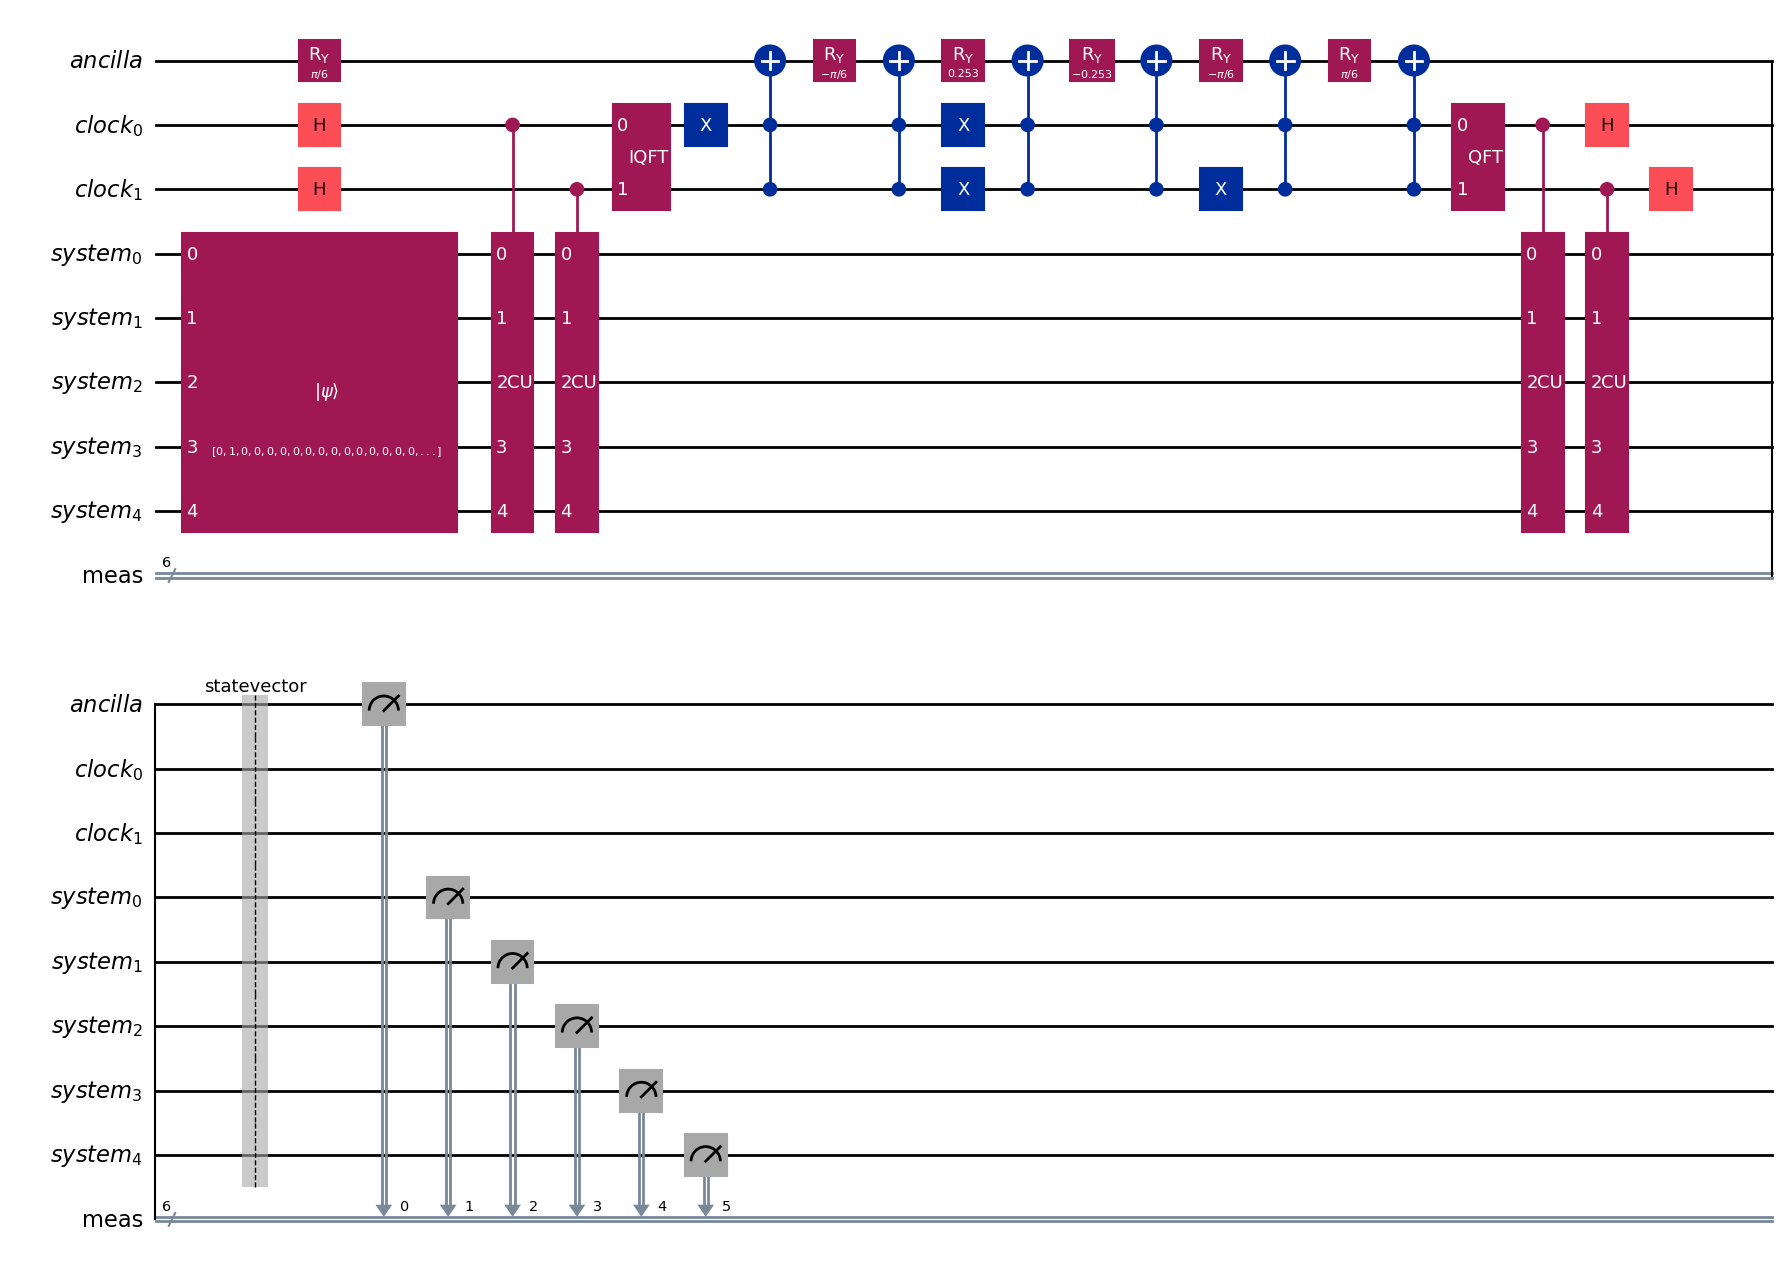

In [23]:
hhl_qc.draw('mpl')

In [24]:
sim        = AerSimulator(method="statevector")
compiled   = transpile(hhl_qc, sim)
result     = sim.run(compiled).result()
state      = np.array(result.get_statevector())

total_q    = 1 + 2 + 5          # ancilla + clock + target = 8
n_clk      = 2
n_tgt      = 5
n_sys_half = 16

solution_raw = np.array([
    state[i] for i in range(len(state))
    if (i & 1) == 1              # ancilla is bit 0
])

sol_indices  = [(n_sys_half + j) << n_clk for j in range(16)]
x_quantum    = np.array([solution_raw[idx] for idx in sol_indices])
x_quantum[np.abs(x_quantum) < 1e-6] = 0

norm            = np.linalg.norm(x_quantum)
x_quantum_norm  = x_quantum / norm if norm > 0 else x_quantum

b_orig    = np.zeros(16, dtype=complex);  b_orig[1] = 1.0
x_cl      = np.linalg.solve(U_matrix.astype(complex), b_orig)
x_cl_norm = x_cl / np.linalg.norm(x_cl)

match = np.allclose(np.abs(x_quantum_norm), np.abs(x_cl_norm), atol=0.05)
print(f"\nQuantum  |x> : {np.round(x_quantum_norm, 4)}")
print(f"Classical|x> : {np.round(x_cl_norm, 4)}")
print(f"Matching?        : {match}")


Quantum  |x> : [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.-0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j
  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
Classical|x> : [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Matching?        : True


The rotation matrix $R(\lambda)$ is defined as:$$R(\lambda) = \begin{pmatrix} \cos(\frac{\theta_\lambda}{2}) & -\sin(\frac{\theta_\lambda}{2}) \\ \sin(\frac{\theta_\lambda}{2}) & \cos(\frac{\theta_\lambda}{2}) \end{pmatrix}$$

The angle $\theta$ is calculated based on the eigenvalue $\lambda$ and a scaling constant $C$:$$\theta_\lambda = 2 \arcsin\left(\frac{C}{\lambda}\right)$$

In [25]:
import numpy as np
from qiskit.circuit.library import RYGate

def get_hhl_rotation_matrix(eigenvalue, C=1.0):
    if eigenvalue < C:
        raise ValueError("Eigenvalue must be >= C to avoid math domain error.")

    theta = 2 * np.arcsin(C / eigenvalue)

    R = np.array([
        [np.cos(theta/2), -np.sin(theta/2)],
        [np.sin(theta/2),  np.cos(theta/2)]
    ])

    return theta, R

# Example for the first non-zero eigenvalue (lambda = 1)
C_const = 1.0
lam = 1.0
angle, matrix = get_hhl_rotation_matrix(lam, C=C_const)

print(f"For lambda = {lam}:")
print(f"Rotation Angle (theta): {angle:.4f} radians")
print("Rotation Matrix R:")
print(matrix)

For lambda = 1.0:
Rotation Angle (theta): 3.1416 radians
Rotation Matrix R:
[[ 6.123234e-17 -1.000000e+00]
 [ 1.000000e+00  6.123234e-17]]


## Margolous Gate

$$\text{M} = \begin{pmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & -1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0
\end{pmatrix}$$

In [26]:
def margolus_gate(qc, c1, c2, t):
    theta = np.pi/4
    # Since pi/8 is in the matrix, the rotation angle is 2*theta
    qc.ry(theta, t)
    qc.cx(c2, t)
    qc.ry(-theta, t)
    qc.cx(c1, t)
    qc.ry(theta, t)
    qc.cx(c2, t)
    qc.ry(-theta, t)

In [27]:
def margolus_conditional_rotation(circuit, clock, ancilla, t, n_clock):
    num_states = 2 ** n_clock
    C_norm = 1.0

    for k in range(1, num_states):
        lam_recon = (k/num_states)*(2*np.pi/t) if k <= num_states//2 else ((k-num_states)/num_states)*(2*np.pi/t)
        theta = 2 * np.arcsin(np.clip(C_norm / lam_recon, -1.0, 1.0))

        k_bin = format(k, f'0{n_clock}b')
        flip_qubits = [clock[i] for i in range(n_clock) if k_bin[i] == '0']

        if flip_qubits: circuit.x(flip_qubits)

        circuit.ry(theta/2, ancilla)
        margolus_gate(circuit, clock[0], clock[1], ancilla) # Simplified CCX
        circuit.ry(-theta/2, ancilla)
        margolus_gate(circuit, clock[0], clock[1], ancilla) # Simplified CCX

        if flip_qubits: circuit.x(flip_qubits)

In [28]:
def build_hhl_circuit_with_margolus(C, b, num_phase_qubits, n_system, n_clock,t):

    qr_a = QuantumRegister(1, 'ancilla')
    qr_c = QuantumRegister(n_clock, 'clock')
    qr_s = QuantumRegister(n_system, 'system')
    cr   = ClassicalRegister(n_system + 1, 'meas')

    qc = QuantumCircuit(qr_a, qr_c, qr_s, cr)

    # b_padded = [b; 0]
    b_padded = np.concatenate([b, np.zeros(len(C) - len(b))])
    b_padded = b_padded / np.linalg.norm(b_padded)
    qc.initialize(b_padded, qr_s)

    qpe(qc, qr_c, qr_s, C, t)
    margolus_conditional_rotation(qc, qr_c, qr_a, t, n_clock)
    inv_qpe(qc, qr_c, qr_s, C, t)

    qc.save_statevector()
    qc.measure(qr_a, cr[0])
    qc.measure(qr_s, cr[1:])

    return qc


In [29]:
warnings.filterwarnings("ignore", category=DeprecationWarning)

qc_marg = build_hhl_circuit_with_margolus(C, b, num_phase_qubits, n_system=5, n_clock=2,t=t_p2)

print("Circuit depth :", hhl_qc.depth())
print("Gate counts   :", dict(hhl_qc.count_ops()))

Circuit depth : 21
Gate counts   : {'ry': 6, 'ccx': 6, 'measure': 6, 'h': 4, 'chamiltonian': 4, 'x': 4, 'initialize': 1, 'IQFT': 1, 'QFT': 1, 'save_statevector': 1}


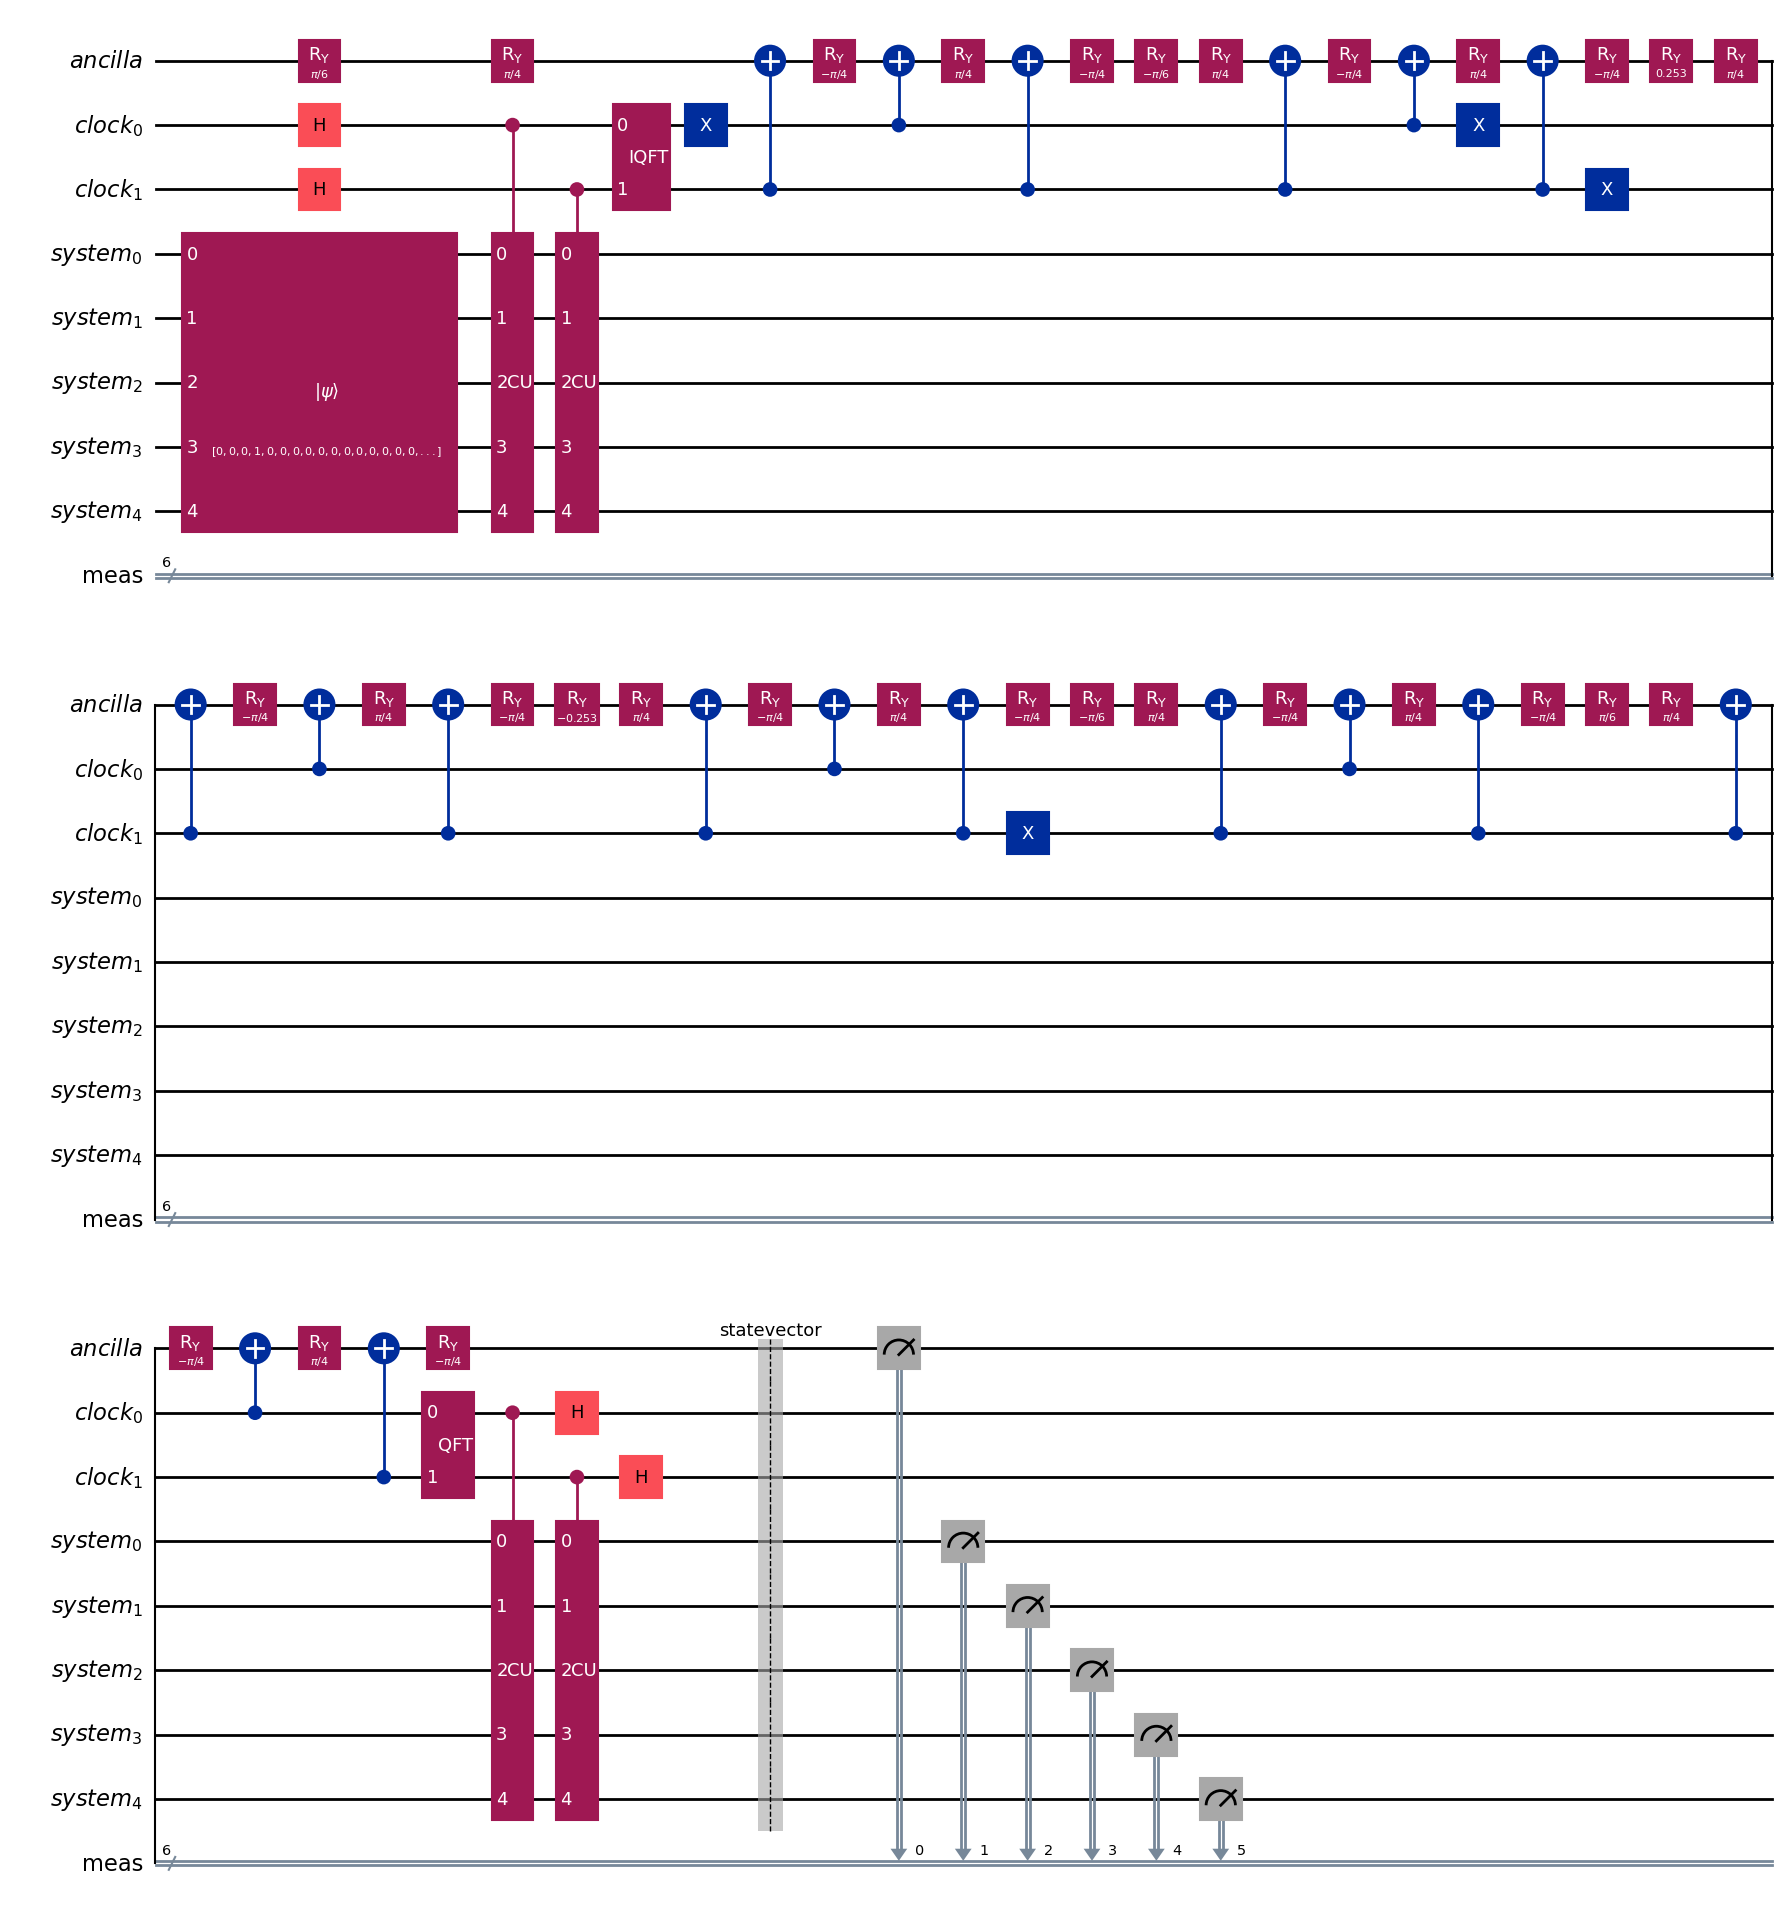

In [30]:
qc_marg.draw("mpl")

In [31]:
# Margolos gate output analysis
sim        = AerSimulator(method="statevector")
compiled   = transpile(qc_marg, sim)
result     = sim.run(compiled).result()
state      = np.array(result.get_statevector())

total_q    = 1 + 2 + 5          # ancilla + clock + target = 8
n_clk      = 2
n_tgt      = 5
n_sys_half = 16

solution_raw = np.array([
    state[i] for i in range(len(state))
    if (i & 1) == 1              # ancilla is bit 0
])

sol_indices  = [(n_sys_half + j) << n_clk for j in range(16)]
x_quantum    = np.array([solution_raw[idx] for idx in sol_indices])
x_quantum[np.abs(x_quantum) < 1e-6] = 0

norm            = np.linalg.norm(x_quantum)
x_quantum_norm  = x_quantum / norm if norm > 0 else x_quantum

b_orig    = np.zeros(16, dtype=complex);  b_orig[1] = 1.0
x_cl      = np.linalg.solve(U_matrix.astype(complex), b_orig)
x_cl_norm = x_cl / np.linalg.norm(x_cl)

match = np.allclose(np.abs(x_quantum_norm), np.abs(x_cl_norm), atol=0.05)
print(f"\nQuantum  |x> : {np.round(x_quantum_norm, 4)}")
print(f"Classical|x> : {np.round(x_cl_norm, 4)}")
print(f"Matching?        : {match}")


Quantum  |x> : [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Classical|x> : [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Matching?        : False


The Margolous Gate fails because of phase interference collapse

HHL relies on perfect constructive interference on the $|1\rangle$ state of the ancilla.

* Standard Toffoli: Preserves the relative phases of the clock register, allowing the "Uncompute" step to perfectly reset the clock qubits to $|00\rangle$.
* Margolus Gate: Introduces a relative phase shift of $\pi$ (a factor of $-1$) on specific states (like $|101\rangle$).

This phase prevents the inverse QFT and the inverse Hamiltonian evolution from working correctly.